# Deterministic Pruning Approaches

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from stochastic_graph import StochasticGraph
from preprocessing import bfReach, detReach, bfArcFlags, detArcFlags
from SOTA import StandardSOTASolver, SingleIterationSOTASolver
from deterministic_algorithms import Dijkstra

sys.path.append(os.path.abspath("../graph"))

from Grid_network_and_Gamma_distribution import Matrix

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

%matplotlib inline

%load_ext autoreload
%autoreload 2

In [26]:
# loading graph

matrix = Matrix(5, 5, link_var_max=0.5)
adj_matrix, var_matrix = matrix.compute_matrices()

## Step-by-step Reach explanation

### 1. Initialization

In [34]:
adj_matrix, var_matrix = matrix.get_matrices()
g = StochasticGraph(adj_matrix, var_matrix)
d = Dijkstra(adj_matrix)

r = detReach(g, d, 20)

### 2. Reach computation
#### 2.1 Computing the optimal path from $start \in V$ to all nodes

`compute_path(start_node)` function computes the optimal path from source node to all nodes and returns a list of predecessors; for each node I'll have the optimal predecessor.

In [35]:
start = 0

pred_s = d.compute_path(start)
pred_s

{0: [],
 1: [0],
 5: [0],
 2: [1],
 6: [1],
 3: [2],
 7: [2],
 11: [6],
 10: [5],
 8: [3],
 12: [7],
 15: [10],
 13: [12],
 17: [16],
 4: [3],
 16: [15],
 20: [15],
 14: [13],
 18: [13],
 9: [8],
 21: [20],
 22: [21],
 19: [14],
 23: [18],
 24: [19]}

#### 2.2 Find set of nodes in at least one optimal path from $s$ to $d$

In [39]:
dest = 24

opt_paths = d.get_all_optimal_paths(pred_s, dest)
print(opt_paths)
visited_edges = d.get_nodes_from_optimal_paths(opt_paths)
print(visited_edges)

[[0, 1, 2, 7, 12, 13, 14, 19, 24]]
{0, 1, 2, 7, 12, 13, 14, 19, 24}


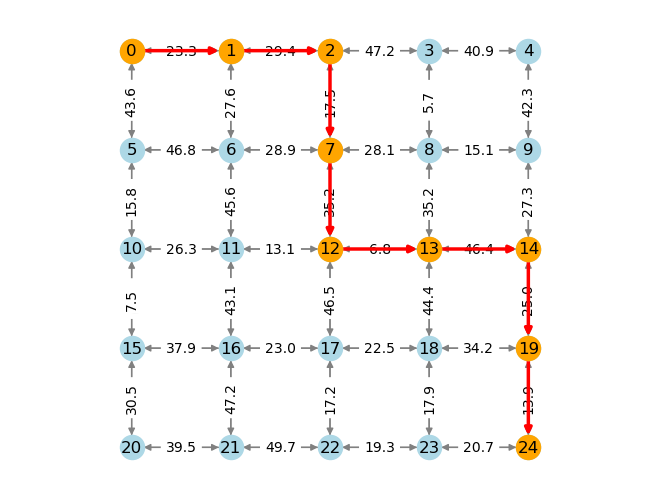

In [40]:
g.print_graph(path=opt_paths[0])

#### 2.3 Updating reach structure

In [42]:
r.print_reach_values()

Reach values for each node:
Node 0: Reach = 23.25
Node 1: Reach = 23.25
Node 2: Reach = 29.44
Node 3: Reach = 40.89
Node 4: Reach = 0.00
Node 5: Reach = 20.13
Node 6: Reach = 29.46
Node 7: Reach = 29.46
Node 8: Reach = 15.14
Node 9: Reach = 27.32
Node 10: Reach = 23.92
Node 11: Reach = 43.06
Node 12: Reach = 35.24
Node 13: Reach = 35.17
Node 14: Reach = 24.98
Node 15: Reach = 20.69
Node 16: Reach = 43.06
Node 17: Reach = 35.29
Node 18: Reach = 22.53
Node 19: Reach = 19.02
Node 20: Reach = 30.51
Node 21: Reach = 39.45
Node 22: Reach = 19.31
Node 23: Reach = 25.33
Node 24: Reach = 20.73


### 3. Pruning

Computing reach values...
Reach values computed
Pruning nodes...
Pruned nodes: {4, 5, 6, 8, 14, 18, 21, 22}


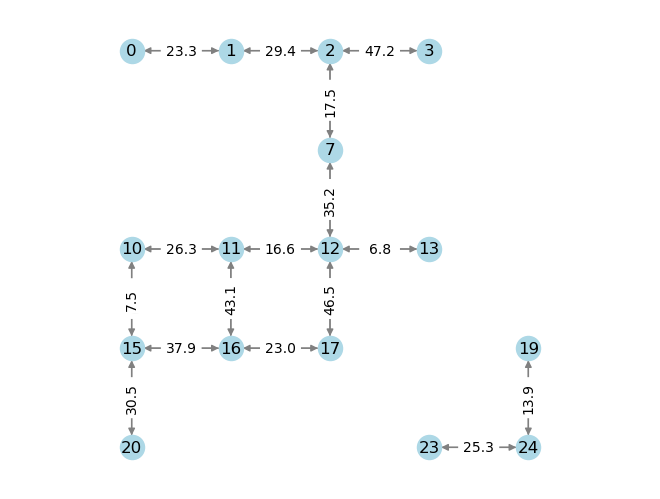

In [41]:
r.reach_computation()
r.reach_pruning()
g.print_graph()

## Step-by-step Arc-flags explanation

### 1. Dividing graph into partitions

We divide the graph into partition using Canopy K-means algorithm.

In [27]:
adj_matrix, var_matrix = matrix.get_matrices()
g = StochasticGraph(adj_matrix, var_matrix)
d = Dijkstra(adj_matrix)

f = detArcFlags(g, d, 20)

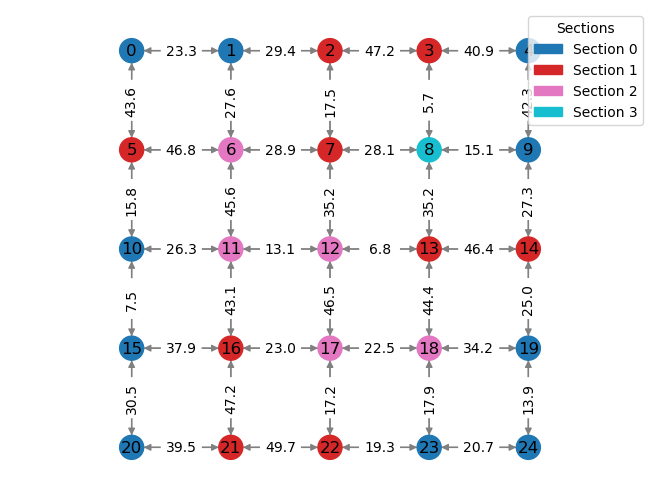

In [28]:
f.partition_graph()
f.print_graph_sections()

### 2. Computing Arcflags

#### 2.1 Computing the optimal path from $start \in V$ to all nodes

`compute_path(start_node)` function computes the optimal path from source node to all nodes and returns a list of predecessors; for each node I'll have the optimal predecessor.

In [29]:
start = 0

pred_s = d.compute_path(start)
pred_s

{0: [],
 1: [0],
 5: [0],
 2: [1],
 6: [1],
 3: [2],
 7: [2],
 11: [6],
 10: [5],
 8: [3],
 12: [7],
 15: [10],
 13: [12],
 17: [16],
 4: [3],
 16: [15],
 20: [15],
 14: [13],
 18: [13],
 9: [8],
 21: [20],
 22: [21],
 19: [14],
 23: [18],
 24: [19]}

Note: if we have multiple predecessors for one or more nodes, I'll get multiple optimal paths.

#### 2.2 For each destination $dest\in V$, I'll get the optimal path and optimal edges set

In [30]:
dest = 18

opt_paths = d.get_all_optimal_paths(pred_s, dest)
print(opt_paths)
visited_edges = d.get_edges_from_optimal_paths(opt_paths)
print(visited_edges)

[[0, 1, 2, 7, 12, 13, 18]]
{(0, 1), (1, 2), (2, 7), (12, 13), (7, 12), (13, 18)}


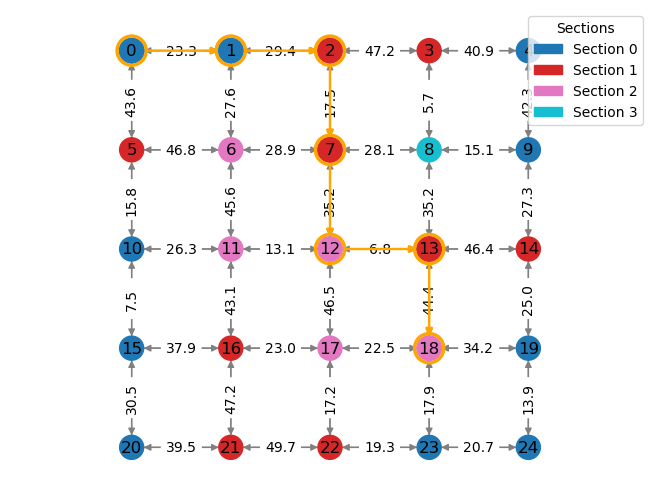

In [31]:
f.print_graph_sections(path=opt_paths[0])

#### 2.3 Updating $AF$ structure

I'll set the corresponding $dest$ region to $\text{TRUE}$ for all the `visited_edges`

### 3. Pruning

In [32]:
f.arcflags_computation()
f.print_arcflags()

Executing partition...
Partitioning of the graph in 4 regions executed in 0.0030 seconds!
Computing arcflags...
Arcflags computed!
Arc-Flags for each edge:
Edge (np.int64(0), np.int64(1)): {0: True, 1: True, 2: True, 3: True}
Edge (np.int64(0), np.int64(5)): {0: True, 1: True, 2: True, 3: False}
Edge (np.int64(1), np.int64(0)): {0: True, 1: True, 2: False, 3: False}
Edge (np.int64(1), np.int64(2)): {0: True, 1: True, 2: True, 3: True}
Edge (np.int64(1), np.int64(6)): {0: False, 1: True, 2: True, 3: False}
Edge (np.int64(2), np.int64(1)): {0: True, 1: True, 2: True, 3: False}
Edge (np.int64(2), np.int64(3)): {0: True, 1: True, 2: False, 3: True}
Edge (np.int64(2), np.int64(7)): {0: True, 1: True, 2: True, 3: False}
Edge (np.int64(3), np.int64(2)): {0: True, 1: True, 2: False, 3: False}
Edge (np.int64(3), np.int64(4)): {0: True, 1: False, 2: False, 3: False}
Edge (np.int64(3), np.int64(8)): {0: True, 1: True, 2: True, 3: True}
Edge (np.int64(4), np.int64(3)): {0: True, 1: True, 2: True, 

I'll retrieve destination region and prune the edge if the arcflag is $=\text{FALSE}$.

Pruning edges...
[ArcFlags] Pruned 7 edges for destination 20 (region 0).


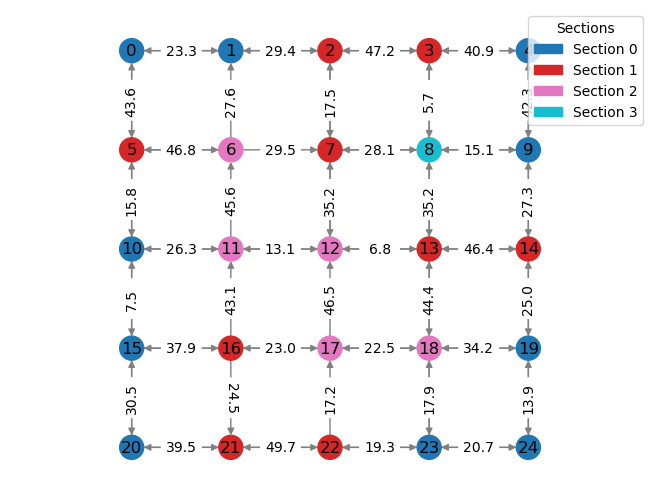

In [33]:
f.arcflags_pruning()
f.print_graph_sections()